In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import flopy

In [2]:
outdir = os.path.join("output")

# READ PTH3D

In [ ]:
def clean_obs_chem(datadir = "data",
                    input_path="obs_chem_raw_0.csv", 
                   output_path="obs_chem_cleaned.csv"):
    """Load, clean, and save obs_chem data by converting units of specific variables."""
    input_path = os.path.join(datadir, input_path)
    output_path = os.path.join(datadir, output_path)
    obsdata = pd.read_csv(input_path)
    obsdata.loc[:, 'obsid'] = obsdata['obsid'].str.lower()

    data_source2 = pd.read_csv(os.path.join("data", "obs_chem_raw_1.csv"))
    to_pull = ['Fe2', 'Fe3', 'tic']
    data_source2=data_source2[data_source2["var"].isin(to_pull)].copy()
    data_source2['units'] = 'mol_l'
    data_source2=data_source2[obsdata.columns]

    obsdata = pd.concat([obsdata, data_source2])

    # Standardize column name
    obsdata.rename(columns={'var': 'variable'}, inplace=True)
    
    # Unit conversions
    unit_conversions = {
        # 'Cl': 1/(58.44*1e3),   # mmol/L → mol/L
        'Tmp': 1e-3,  # apply scaling to be consistent with outputs
    }

    for var, factor in unit_conversions.items():
        obsdata.loc[obsdata['variable'] == var, 'value'] *= factor

    # Save cleaned file
    obsdata.to_csv(output_path, index=False, float_format="%.5e")

    return obsdata


In [46]:
clean_obs_chem()

,obsid,variable,time,value,units
0,wp1-f1,O0,0.000000,0.000475,mol_l
1,wp1-f1,O0,112.052083,0.000144,mol_l
2,wp1-f1,O0,140.014583,0.000125,mol_l
3,wp1-f1,O0,196.054167,0.000150,mol_l
4,wp1-f1,O0,518.054167,0.000138,mol_l
...,...,...,...,...,...
4336,wp4-f1,tic,0.000000,0.008486,mol_l
4337,wp4-f1,tic,517.980000,0.008513,mol_l
4338,wp4-f1,tic,700.000000,0.010829,mol_l
4339,wp4-f5,tic,0.000000,0.008833,mol_l


In [20]:
sorted(obsdata.variable.unique())

['Ca', 'Cl', 'Fe', 'HCO3', 'NO3', 'Na', 'O2', 'SO4', 'Tmp', 'pH']

In [22]:
sorted(obsdata.variable.unique())

['Ca', 'Cl', 'Fe2', 'HCO3', 'NO3', 'Na', 'O0', 'SO4', 'Tmp', 'pH', 'tic']

In [ ]:
import numpy as np
import os

# Model dimensions
mcols = 51
mrows = 10
mlays = 12
j_cross =10 

# Load data arrays
pht3d002 = np.loadtxt(os.path.join("data", "PHT3D002.ucn"))
pht3d011 = np.loadtxt(os.path.join("data", "PHT3D011.ucn"))
pht3d014 = np.loadtxt(os.path.join("data", "PHT3D014.ucn"))

# Calculate mtime from array length
mtime = len(pht3d002) // (mlays * mcols * mrows)

# Define extraction points
extraction_points = {
    'wp1': {
        'i': 26,
        'layers': {12: 'f1', 8: 'f2', 4: 'f3', 2: 'f4', 1: 'f5'}
    },
    'wp3': {
        'i': 35,
        'layers': {10: 'f1', 8: 'f2', 5: 'f3', 2: 'f4', 1: 'f5'}
    },
    'injection': {
        'i': 39,
        'layers': {2: ''}
    }
}

# Initialize results dictionary
results = {}
for point, config in extraction_points.items():
    for layer, filter_name in config['layers'].items():
        suffix = f"_{filter_name}" if filter_name else ""
        for chemical in ['hco3', 'no3', 'so4']:
            key = f"{chemical}_{point}{suffix}_pht3d"
            results[key] = np.zeros(mtime)

# Chemical data mapping
chemical_data = {
    'hco3': pht3d002,
    'no3': pht3d011,
    'so4': pht3d014
}

# Extract data
nr = 0
for t in range(mtime):
    for lay in range(1, mlays + 1):
        for j in range(1, mrows + 1):
            for i in range(1, mcols + 1):
                if j == j_cross:
                    # Check each extraction point
                    for point, config in extraction_points.items():
                        if i == config['i'] and lay in config['layers']:
                            filter_name = config['layers'][lay]
                            suffix = f"_{filter_name}" if filter_name else ""
                            
                            # Extract all chemicals at this point
                            for chemical, data_array in chemical_data.items():
                                key = f"{chemical}_{point}{suffix}_pht3d"
                                results[key][t] = data_array[nr]
                
                nr += 1

# Results are now in the results dictionary
# e.g., results['hco3_wp1_f1_pht3d'], results['no3_wp3_f2_pht3d'], etc.
len(results['hco3_wp1_f1_pht3d'])
mtime

In [ ]:
len(pht3d002)

# OBS DATA

In [4]:
obsdata = pd.read_csv(os.path.join("data", "obs_chem_cleaned.csv"))


In [ ]:
ucn_files = [f for f in os.listdir("data") if f.lower().endswith('.ucn')]
ucn_files[19]
arr = np.loadtxt(os.path.join("data", ucn_files[19]))
54614
len(arr)

In [ ]:
arr

In [ ]:
# for obsid, obs_df in obsdata.groupby('obsid'):
#     vars_ = obs_df['var'].unique()
#     n_vars = len(vars_)

#     fig, axes = plt.subplots(
#         n_vars, 1,
#         figsize=(6.3, 3 * n_vars),
#         sharex=True
#     )
#     if n_vars == 1:                # ensure axes is iterable when only one subplot
#         axes = [axes]
#     for ax, var in zip(axes, vars_):
#         vdf = obs_df[obs_df['var'] == var]
#         ax.scatter(vdf['days'], vdf['value'], marker='o')
#         ax.set_ylabel(f"{var} ({vdf['units'].iloc[0]})")
#         ax.set_title(f"{obsid} – {var}")
#         ax.grid(True)


#     axes[-1].set_xlabel("Days")
#     fig.suptitle(f"Time Series for {obsid}", fontsize=14, y=1.02)
#     fig.tight_layout()
#     # fig.savefig(f"{obsid}.png", dpi=300)    # uncomment to save

#     plt.show()

# EXPORT VTK

In [ ]:
ws = os.path.join("model", "reactive")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
gwf = sim.get_model("gwf")
obs = flopy.utils.observationfile.Mf6Obs(os.path.join(ws,'obs_Cl.csv'),isBinary=False)
obs.get_nobs()

# model_name = 'dizon36'
# gwf.dis.idomain.export(os.path.join(outdir, f"{model_name}.vtk"), fmt="vtk")
# gwf.wel[0].export(os.path.join(outdir, f"{model_name}.vtk"), fmt="vtk")
# gwf.wel[1].export(os.path.join(outdir, f"{model_name}.vtk"), fmt="vtk")
# gwf.npf.k.export(os.path.join(outdir, f"{model_name}.vtk"), fmt="vtk")
# gwf.chd.export(os.path.join(outdir, f"{model_name}.vtk"), fmt="vtk")

# HEADS

In [ ]:
# Get the time discretization information
tdis = gwf.simulation.tdis
perioddata = tdis.perioddata.get_data()
nlay = gwf.dis.nlay.get_data()


# Calculate cumulative end times from each stress period
cumulative_time = 0
end_of_stress_period_times = []
for perlen in perioddata["perlen"]:
    cumulative_time += perlen
    end_of_stress_period_times.append(cumulative_time)

# plot heads in mapview for each layer
h = gwf.output.head().get_alldata()

# plot the head results mapview
mapview_output_dir = os.path.join(ws, 'output', 'mapview')
if not os.path.exists(mapview_output_dir):
    os.makedirs(mapview_output_dir)


mapview_counter = 0
for t in range(38, 39):
    h_t = h[t, :, :, :]
    cell=np.zeros_like(h_t)
    cell[0, 0, 0]=10
    masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
    vmin = masked_h.min()
    vmax = masked_h.max()
    vmin, vmax = np.nanmin(masked_h), np.nanmax(masked_h)  # Set colorbar limits

    contour_intervals = np.linspace(vmin, vmax, 20)  # Contour levels

    #contour_intervals = np.arange(vmin, vmax, (vmax-vmin)/10)
    
    # Create a figure with 4 rows and 3 columns
    fig, axes = plt.subplots(4, 3, figsize=(16, 16), constrained_layout=True)
    fig.subplots_adjust(right=0.85)  # Leave space for the colorbar
    
    # Loop over all layers
    for i, ax in enumerate(axes.flat):
        if i < nlay:
            # Plot for layer `i`
            ax.set_title(f"Model Layer {i + 1}")
            modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=i)
    
            # Plot array, boundary conditions, and contours
            # pa = modelmap.plot_array(masked_h[i, :, :], vmin=vmin, vmax=vmax)
            
            pa = modelmap.plot_array(cell[i, :, :], vmin=vmin, vmax=vmax)
            modelmap.plot_bc("WEL", color='black')
            # modelmap.plot_bc("CHD", color='blue')
            modelmap.plot_grid(lw=0.5, color="0.5")
            # contours = modelmap.contour_array(
            #     masked_h[i, :, :],
            #     levels=contour_intervals,
            #     colors="black",
            # )
            # ax.clabel(contours, fmt="%2.1f")
        else:
            # Hide axes for extra subplots
            ax.axis("off")
    
    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pa, cax=cbar_ax, label="Head (mamsl)")
    plt.suptitle('Simulated Head at Stress Period: ' + str(t+1) + ' time in days: ' + str(end_of_stress_period_times[t]))
    # Use tight_layout for clean subplot spacing
    #fig.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the colorbar
    # fig.savefig(os.path.join('000' + str(mapview_counter) + '_SimulatedHeads_mamsl_nper_' + str(t+1) + '_time_days_' + str(end_of_stress_period_times[t]) + '.png'), dpi=400, bbox_inches='tight')
    #plt.close(fig)
    mapview_counter+=1
    plt.show()

In [ ]:
# Get the time discretization information
gwf = sim.get_model("S")

tdis = gwf.simulation.tdis
perioddata = tdis.perioddata.get_data()
nlay = gwf.dis.nlay.get_data()


# Calculate cumulative end times from each stress period
cumulative_time = 0
end_of_stress_period_times = []
for perlen in perioddata["perlen"]:
    cumulative_time += perlen
    end_of_stress_period_times.append(cumulative_time)

# plot heads in mapview for each layer
h = gwf.output.concentration().get_alldata()

# plot the head results mapview
mapview_output_dir = os.path.join(ws, 'output', 'mapview')
if not os.path.exists(mapview_output_dir):
    os.makedirs(mapview_output_dir)


mapview_counter = 0
for t in [0, 10, 20, 30]:
    h_t = h[t, :, :, :]
    cell=np.zeros_like(h_t)
    cell[0, 0, 0]=10
    # masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
    vmin = h.min()
    vmax = h.max()
    # vmin, vmax = np.nanmin(masked_h), np.nanmax(masked_h)  # Set colorbar limits

    contour_intervals = np.linspace(vmin, vmax, 20)  # Contour levels

    #contour_intervals = np.arange(vmin, vmax, (vmax-vmin)/10)
    
    # Create a figure with 4 rows and 3 columns
    fig, axes = plt.subplots(4, 3, figsize=(16, 16), constrained_layout=True)
    fig.subplots_adjust(right=0.85)  # Leave space for the colorbar
    
    # Loop over all layers
    for i, ax in enumerate(axes.flat):
        if i < nlay:
            # Plot for layer `i`
            ax.set_title(f"Model Layer {i + 1}")
            modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=i)
    
            # Plot array, boundary conditions, and contours
            pa = modelmap.plot_array(h_t[i, :, :], 
                                     vmin=vmin, 
                                     vmax=vmax
                                     )
            
            # pa = modelmap.plot_array(cell[i, :, :], vmin=vmin, vmax=vmax)
            # modelmap.plot_bc("WEL", color='black')
            # modelmap.plot_bc("CHD", color='blue')
            modelmap.plot_grid(lw=0.5, color="0.5")
            # contours = modelmap.contour_array(
            #     masked_h[i, :, :],
            #     levels=contour_intervals,
            #     colors="black",
            # )
            # ax.clabel(contours, fmt="%2.1f")
        else:
            # Hide axes for extra subplots
            ax.axis("off")
    
    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pa, cax=cbar_ax, label="Head (mamsl)")
    plt.suptitle(' time in days: ' + str(t))
    # Use tight_layout for clean subplot spacing
    #fig.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the colorbar
    # fig.savefig(os.path.join('000' + str(mapview_counter) + '_SimulatedHeads_mamsl_nper_' + str(t+1) + '_time_days_' + str(end_of_stress_period_times[t]) + '.png'), dpi=400, bbox_inches='tight')
    #plt.close(fig)
    mapview_counter+=1
    plt.show()

In [ ]:
vmin

In [ ]:
h.shape

In [ ]:
cell[0,0,0]

# DIS MAPS AND XSECTIONS

In [ ]:
gwt = sim.get_model("Tmp")
gwf = sim.get_model("gwf")

tdis = gwf.simulation.tdis
perioddata = tdis.perioddata.get_data()
nlay = gwf.dis.nlay.get_data()

# plot heads in mapview for each layer
h = gwt.output.concentration().get_alldata()
# masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
vmin = h.min()
vmax = h.max()
obs1 = (7, 0, 20)  # Layer, row, and column for observation 1
obs2 = (7, 0, 30)  # Layer, row, and column for observation 2        
xgrid, _, zgrid = gwf.modelgrid.xyzcellcenters
k=gwf.npf.k.get_data()
# vmin = k.min()
# vmax = k.max()
fig, ax = plt.subplots(1, 1, figsize=(9, 4), constrained_layout=True)
modelmap = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"row": 9},geographic_coords=True)
pa = modelmap.plot_array(h[105,:,:,:], vmin=vmin, vmax=vmax)
# pa = modelmap.plot_array(k, vmin=vmin, vmax=vmax)

quadmesh = modelmap.plot_bc("WEL")
quadmesh2 = modelmap.plot_bc("chd")
for k, i, j in [obs1, obs2]:
            x = xgrid[i, j]
            z = zgrid[k, i, j]
            ax.plot(x, z, mfc="yellow", mec="black", marker="o", ms="8")
linecollection = modelmap.plot_grid(lw=0.5, color="0.5")
cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(pa, cax=cbar_ax, label="Head (mamsl)")


In [ ]:
h[500,:,:,:]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4), constrained_layout=True)
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=1)
# pa = modelmap.plot_array(h, vmin=vmin, vmax=vmax)
quadmesh = modelmap.plot_bc("WEL")
linecollection = modelmap.plot_grid(lw=0.5, color="0.5")


# OBS VS SIM

# Cl non reactive transport

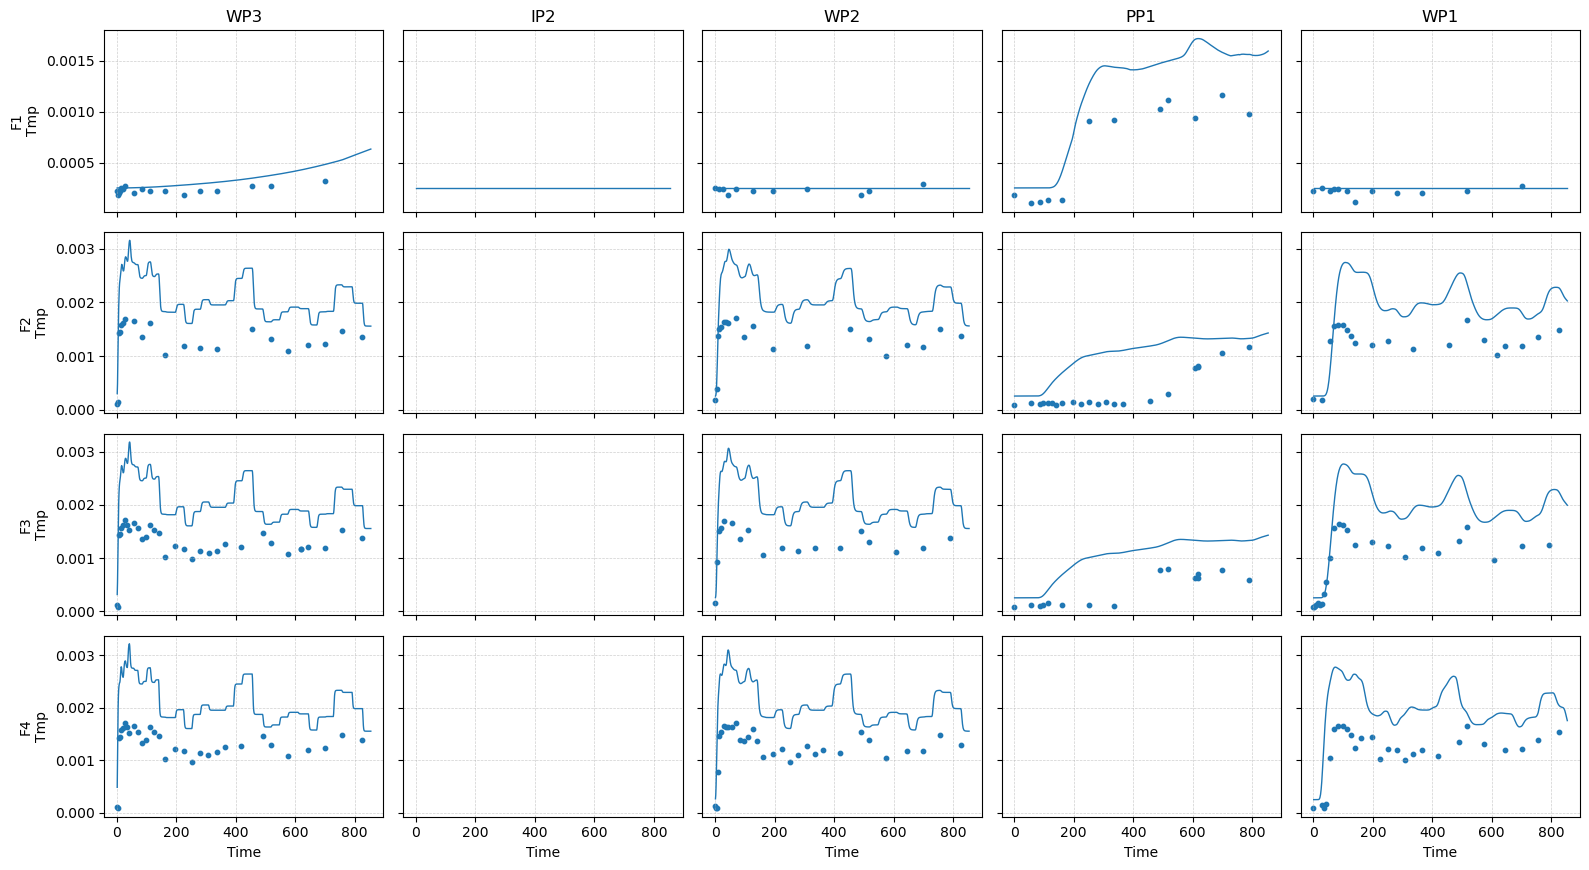

In [12]:
ws = os.path.join("model", "reactive")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,
                                  sim_name = 'gwf', 
                                  version='mf6',
                                    exe_name='mf6',
                                    verbosity_level=0)
gwf = sim.get_model("gwf")

obsdata = pd.read_csv(os.path.join("data", "obs_chem_cleaned.csv"))
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['variable'] == 'Cl' ]

cl = pd.read_csv(os.path.join(ws, "obs_Cl.csv"))
cl = cl.melt(var_name='obsid', value_name=f'Cl', id_vars=['time'])
cl['obsid'] = cl['obsid'].str.lower()

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()
nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time'], lines['Cl']*1e-3, lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + "\nTmp")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # ax.set_ylim(0,30)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()


In [ ]:
cl

In [ ]:
gwf.dis.botm.get_data()

top = gwf.dis.top.array
botm = gwf.dis.botm.array
thickness = np.diff(np.concatenate([top[np.newaxis], botm]), axis=0)

In [ ]:
thickness[-5]

In [ ]:
obsdata['var'].unique()

In [ ]:
# ws = os.path.join("model", "nonreactive")
# sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
# gwf = sim.get_model("gwf")

# to_plot = 'O'

# obsdata = pd.read_csv(os.path.join("data", "obs_chem.csv"))
# obsdata['obsid'] = obsdata['obsid'].str.lower()
# cldata = obsdata[obsdata['var'] == to_plot]

# cl = pd.read_csv(os.path.join(ws, f"obs_{to_plot}.csv"))
# cl = cl.melt(var_name='obsid', value_name=f'{to_plot.lower()}', id_vars=['time'])
# cl['obsid'] = cl['obsid'].str.lower()
# cl

# cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
# cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# # Drop rows you don’t want (already removed f5 above)
# cl = cl[~cl['f'].eq('f5')]
# cl = cl[~cl['wp'].eq('wp4')]

# wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
# fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
# wps.reverse()
# nrow, ncol = len(fs), len(wps)

# fig, axes = plt.subplots(
#     nrow, ncol,
#     figsize=(3.2 * ncol, 2.2 * nrow),
#     sharex='col', sharey='row'
# )
# # axes is a 2‑D array even if any dimension is 1
# axes = np.atleast_2d(axes)

# # ------------------------------------------------------------------
# # 2)  Loop over the grid
# # ------------------------------------------------------------------
# for r, f in enumerate(fs):
#     for c, wp in enumerate(wps):
#         ax = axes[r, c]

#         mask  = (cl['wp'] == wp) & (cl['f'] == f)
#         lines = cl.loc[mask]
#         if not lines.empty:
#             ax.plot(lines['time'], lines[f'{to_plot.lower()}'], lw=1)

#             data_pts = cldata[
#                 (cldata['obsid'].str.contains(wp, case=False)) &
#                 (cldata['obsid'].str.contains(f,  case=False))
#             ]
#             if not data_pts.empty:
#                 ax.scatter(data_pts['days'], data_pts['value'], s=10)

#         # Formatting
#         if r == 0:                       # top row → column titles
#             ax.set_title(wp.upper())
#         if c == 0:                       # first col → y‑label per row
#             ax.set_ylabel(f.upper() + f"\n{to_plot}")
#         ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# # Shared labels
# for ax in axes[-1, :]:
#     ax.set_xlabel("Time")

# fig.tight_layout()
# plt.show()


In [ ]:
cl

In [ ]:
cl

In [ ]:
ws = os.path.join("model", "reactive_pest")
# ws = os.path.join("model", "Tmp")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,
                                  sim_name = 'gwf', 
                                  version='mf6',
                                    exe_name='mf6',
                                    verbosity_level=0)
sout = pd.read_csv(os.path.join(ws, "sout.csv"))
sout

In [ ]:
gwf = sim.get_model("gwf")


In [ ]:
sout.columns

In [ ]:
cells = sout['cell'].astype(int).unique()

In [ ]:
from flopy.utils.gridintersect import GridIntersect

nlay = gwf.dis.nlay.get_data()
ncol = gwf.dis.ncol.get_data()
nrow = gwf.dis.nrow.get_data()

ix = GridIntersect(gwf.modelgrid)
obsloc = pd.read_csv(os.path.join("data", "obs_loc.csv"))

obs_list=[]

for obsid in obsloc.obsid.unique():
    x,y = obsloc.loc[obsloc.obsid==obsid,['x','y']].values[0]
    cellid = ix.intersect([(x,y)],shapetype="point").cellids
    if len(cellid)==0:
        continue
    else:
        cellid = cellid[0]
        obs_layer = int(obsloc.loc[obsloc.obsid==obsid,'layer'].values[0])
        obs_list.append((obsid, 'concentration', (obs_layer, cellid[0], cellid[1])))
obs_list

wells = pd.DataFrame(obs_list)
wells.columns = ['obsid', 'n', 'cell']
wells['flat_index'] = [cell[0] * (nrow * ncol) + cell[1] * ncol + cell[2] for cell in wells.cell]
wells

obs_to_index = dict(zip(wells['flat_index'], wells['obsid'].str.lower()))
obs_to_index

sout['cell'] = sout['cell'].astype(int)
sout['obsid'] = sout['cell'].map(obs_to_index)
sel = sout.dropna(subset='obsid', inplace=False).copy()

In [ ]:
# ws = os.path.join("model")


to_plot = 'NO3'

obsdata = pd.read_csv(os.path.join("data", "obs_chem_v2.csv"))
print(obsdata['var'].unique())
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['var'] == to_plot]

cl = sel[['time_d', to_plot, 'obsid']].copy()
# cl = cl.melt(var_name='obsid', value_name=f'TOT_N5', id_vars=['time_d'])
cl['obsid'] = cl['obsid'].str.lower()
cl

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]
cl = cl[~cl['wp'].eq('pp1')]
cl = cl[~cl['wp'].eq('ip2')]
cl = cl[cl['f'].eq('f2')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()

nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time_d'], lines[to_plot], lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + f"\n{to_plot}")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # ax.set_ylim(0,1e-2)
        ax.set_ylim(0,6e-4)
        # ax.set_ylim(6,8)
        # ax.set_xlim(0,870)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()


In [ ]:
cldata

In [ ]:
# ws = os.path.join("model")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
gwf = sim.get_model("gwf")

to_plot = 'pH'

obsdata = pd.read_csv(os.path.join("data", "obs_chem_v2.csv"))
print(obsdata['var'].unique())
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['var'] == to_plot]

# cl = pd.read_csv(os.path.join(ws, f"obs_{to_plot}.csv"))
plot_name = 'LA_H'
cl = sel[['time_d', to_plot, 'obsid']].copy()
# cl = cl.melt(var_name='obsid', value_name=f'TOT_N5', id_vars=['time_d'])
cl['obsid'] = cl['obsid'].str.lower()
cl

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]
cl = cl[~cl['wp'].eq('pp1')]
cl = cl[~cl['wp'].eq('ip2')]
cl = cl[cl['f'].eq('f2')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()

nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time_d'], lines[plot_name], lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + f"\n{to_plot}")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # ax.set_ylim(0,1e-2)
        # ax.set_ylim(0,6.5e-4)
        ax.set_ylim(6,8)
        # ax.set_xlim(0,870)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()


In [ ]:
# ws = os.path.join("model")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
gwf = sim.get_model("gwf")

to_plot = 'tic'

obsdata = pd.read_csv(os.path.join("data", "obs_chem_v2.csv"))
print(obsdata['var'].unique())
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['var'] == to_plot]

# cl = pd.read_csv(os.path.join(ws, f"obs_{to_plot}.csv"))
tototo = 'C4'
cl = sel[['time_d', tototo, 'obsid']].copy()
# cl = cl.melt(var_name='obsid', value_name=f'TOT_N5', id_vars=['time_d'])
cl['obsid'] = cl['obsid'].str.lower()
cl

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]
cl = cl[~cl['wp'].eq('pp1')]
cl = cl[~cl['wp'].eq('ip2')]
cl = cl[cl['f'].eq('f2')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()

nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time_d'], lines[tototo], lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + f"\n{to_plot}")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # ax.set_ylim(0,1e-2)
        # ax.set_ylim(0,6.5e-4)
        # ax.set_ylim(6,8)
        # ax.set_xlim(0,870)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()


In [ ]:
# ws = os.path.join("model")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
gwf = sim.get_model("gwf")

to_plot = 'SO4'

obsdata = pd.read_csv(os.path.join("data", "obs_chem_v2.csv"))
print(obsdata['var'].unique())
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['var'] == to_plot]

# cl = pd.read_csv(os.path.join(ws, f"obs_{to_plot}.csv"))

cl = sel[['time_d', to_plot, 'obsid']].copy()
# cl = cl.melt(var_name='obsid', value_name=f'TOT_N5', id_vars=['time_d'])
cl['obsid'] = cl['obsid'].str.lower()
cl

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]
cl = cl[~cl['wp'].eq('pp1')]
cl = cl[~cl['wp'].eq('ip2')]
cl = cl[cl['f'].eq('f2')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()

nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time_d'], lines[to_plot], lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + f"\n{to_plot}")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # ax.set_ylim(0,1e-2)
        # ax.set_ylim(0,6.5e-4)
        # ax.set_ylim(6,8)
        # ax.set_xlim(0,870)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()


In [ ]:
# ws = os.path.join("model")
sim = flopy.mf6.MFSimulation.load(sim_ws = ws,sim_name = 'gwf', version='mf6', exe_name='mf6' )
gwf = sim.get_model("gwf")

to_plot = 'O0'

obsdata = pd.read_csv(os.path.join("data", "obs_chem_v2.csv"))
print(obsdata['var'].unique())
obsdata['obsid'] = obsdata['obsid'].str.lower()
cldata = obsdata[obsdata['var'] == to_plot]

# cl = pd.read_csv(os.path.join(ws, f"obs_{to_plot}.csv"))
cl = sel[['time_d', to_plot, 'obsid']].copy()
# cl = cl.melt(var_name='obsid', value_name=f'TOT_N5', id_vars=['time_d'])
cl['obsid'] = cl['obsid'].str.lower()
cl

cl['wp'] = cl['obsid'].str.extract(r'((?:wp|ip|pp)\d+)', expand=False)
cl['f']  = cl['obsid'].str.extract(r'(f\d+)',  expand=False)

# Drop rows you don’t want (already removed f5 above)
cl = cl[~cl['f'].eq('f5')]
cl = cl[~cl['wp'].eq('wp4')]
cl = cl[~cl['wp'].eq('pp1')]
cl = cl[~cl['wp'].eq('ip2')]
cl = cl[cl['f'].eq('f2')]

wps = sorted(cl['wp'].unique(), key=lambda s: int(s[2:]))   # wp1, wp2, …
fs  = sorted(cl['f'].unique(),  key=lambda s: int(s[1:]))   # f1,  f2,  …
wps.reverse()

nrow, ncol = len(fs), len(wps)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(3.2 * ncol, 2.2 * nrow),
    sharex='col', sharey='row'
)
# axes is a 2‑D array even if any dimension is 1
axes = np.atleast_2d(axes)

# ------------------------------------------------------------------
# 2)  Loop over the grid
# ------------------------------------------------------------------
for r, f in enumerate(fs):
    for c, wp in enumerate(wps):
        ax = axes[r, c]

        mask  = (cl['wp'] == wp) & (cl['f'] == f)
        lines = cl.loc[mask]
        if not lines.empty:
            ax.plot(lines['time_d'], lines[to_plot], lw=1)

            data_pts = cldata[
                (cldata['obsid'].str.contains(wp, case=False)) &
                (cldata['obsid'].str.contains(f,  case=False))
            ]
            if not data_pts.empty:
                ax.scatter(data_pts['time'], data_pts['value'], s=10)

        # Formatting
        if r == 0:                       # top row → column titles
            ax.set_title(wp.upper())
        if c == 0:                       # first col → y‑label per row
            ax.set_ylabel(f.upper() + f"\n{to_plot}")
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        ax.set_ylim(0,1e-3)
        # ax.set_ylim(0,6.5e-4)
        # ax.set_ylim(6,8)
        # ax.set_xlim(0,870)

# Shared labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()
